# Measured HVAC electricity validation

This notebook evaluates a transparent one-week-ahead HVAC electricity model on the measured EnergyDetective 2020 dataset. The split is chronological: training through June 2016, interval calibration during July to December 2016, and untouched testing during 2017.

The task validates hourly HVAC electricity prediction for buildings with one week of prior target history. It does not validate indoor temperature, comfort, equipment physics, or causal energy savings.

In [1]:
from pathlib import Path
import json, os, sys
import pandas as pd
import matplotlib.pyplot as plt
repo = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(repo / 'src'))
from building_hvac_twin.measured_validation import run_energy_detective_validation
candidate = Path(os.environ.get('HVACTWIN_ENERGY_DATA', repo / 'datasets/external/energy_detective_2020_v2'))
if not candidate.exists():
    for fallback in (repo / '../measured_raw/energy_detective', repo / '../../../measured_raw/energy_detective'):
        if fallback.resolve().exists(): candidate = fallback.resolve(); break
print('Repository:', repo.resolve())
print('Measured dataset:', candidate)
print('Dataset exists:', candidate.exists())

Repository: /root/sessions/481_repository-analysis-inquiry/origin_hvac
Measured dataset: /root/sessions/481_repository-analysis-inquiry/measured_raw/energy_detective
Dataset exists: True


In [2]:
summary = run_energy_detective_validation(candidate, repo / 'outputs/measured_energy_detective')
a = summary['aggregate']
print('Scientific status:', summary['scientific_status'])
print('Prediction task:', summary['prediction_task'])
print('Buildings:', a['buildings'])
print(f"Median model CVRMSE: {a['median_model_cvrmse_percent']:.3f}%")
print(f"Median weekly-persistence CVRMSE: {a['median_persistence_cvrmse_percent']:.3f}%")
print(f"Model better than persistence: {a['model_better_than_persistence_count']}/{a['buildings']}")
print(f"Median empirical 95% interval coverage: {a['median_interval_coverage']:.3f}")

Scientific status: Measured-data Level 1 validation for hourly HVAC electricity prediction only
Prediction task: One-week-ahead HVAC electricity prediction using weather, calendar, and the value from 168 hours earlier
Buildings: 20
Median model CVRMSE: 76.634%
Median weekly-persistence CVRMSE: 89.185%
Model better than persistence: 18/20
Median empirical 95% interval coverage: 0.952


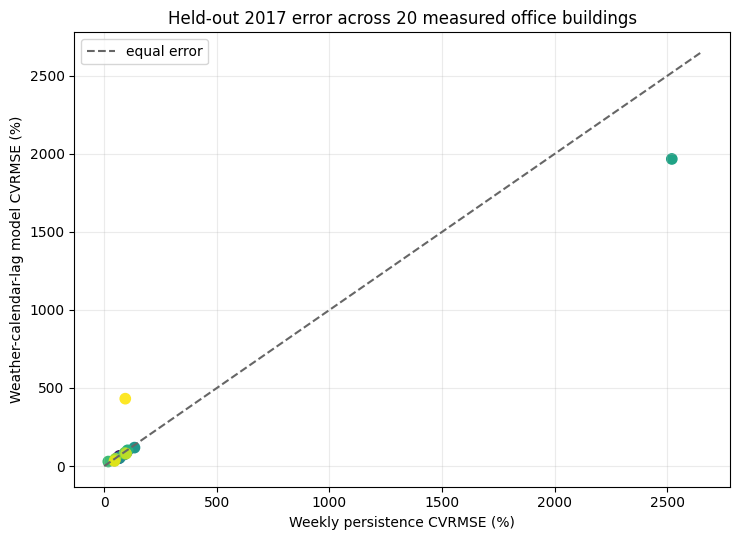

In [3]:
metrics = pd.read_csv(repo / 'outputs/measured_energy_detective/per_building_metrics.csv')
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(metrics.persistence_cvrmse_percent, metrics.model_cvrmse_percent, c=metrics.building_id, cmap='viridis', s=55)
lim = max(metrics.persistence_cvrmse_percent.max(), metrics.model_cvrmse_percent.max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color='0.4', label='equal error')
ax.set(xlabel='Weekly persistence CVRMSE (%)', ylabel='Weather-calendar-lag model CVRMSE (%)', title='Held-out 2017 error across 20 measured office buildings')
ax.legend(); ax.grid(alpha=.25); plt.tight_layout(); plt.show()

In [4]:
best = metrics.assign(improvement=metrics.persistence_cvrmse_percent-metrics.model_cvrmse_percent).sort_values('improvement', ascending=False)
print('Per-building median model CVRMSE (%):', round(metrics.model_cvrmse_percent.median(), 3))
print('Best improvement over persistence (percentage points):', round(best.improvement.iloc[0], 3))
print('Worst change versus persistence (percentage points):', round(best.improvement.iloc[-1], 3))
print('\nFive strongest improvements:')
display(best[['building_id','model_cvrmse_percent','persistence_cvrmse_percent','interval_coverage','improvement']].head())
print('\nInterpretation: the model improves RMSE for most buildings, but errors remain large and two buildings do not beat persistence. This is a measured benchmark result, not production validation.')

Per-building median model CVRMSE (%): 76.634
Best improvement over persistence (percentage points): 552.654
Worst change versus persistence (percentage points): -338.073

Five strongest improvements:


,building_id,model_cvrmse_percent,persistence_cvrmse_percent,interval_coverage,improvement
11,11,1966.769570,2519.423540,0.897603,552.653969
17,17,79.792066,97.242791,0.951598,17.450725
9,9,51.804550,68.657327,0.951826,16.852778
10,10,118.188938,134.354779,0.910845,16.165842
3,3,50.124158,64.483471,0.938356,14.359313



Interpretation: the model improves RMSE for most buildings, but errors remain large and two buildings do not beat persistence. This is a measured benchmark result, not production validation.
